# Exploratory Data Analysis (EDA) : Sequential Classifier for Locomotion Modes with Constrained Temporal Post-Filtering

## 1. Introduction
This notebook performs exploratory data analysis on the gait transition dataset. The dataset contains IMU data from two foot-mounted sensors during various gait modes and transitions between them.

### 1.1 Project Overview
The goal is to develop a hybrid system combining:
1. A sequential deep learning classifier (LSTM/CNN-LSTM)
2. A symbolic post-processing module for temporal consistency

Gait modes: LW (Level Walking), SA (Stair Ascent), SD (Stair Descent), RA (Ramp Ascent), RD (Ramp Descent)

Transitions allowed: LW ↔ SA, LW ↔ SD, LW ↔ RA, LW ↔ RD

## 2. Setup and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import glob
import json
from collections import Counter
from scipy import stats
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# For interactive plots
%matplotlib inline

### 2.1 Configuration

In [10]:
# Configuration dictionary
CONFIG = {
    'data_path': 'C:\\Users\\manel\\Documents\\gait-mode-classifier\\data\\combined',  # Update this to your data path
    'sampling_rate': 100,  # 100 Hz
    'subjects': [f'S{i}' for i in range(1, 11)],
    'gait_modes': {
        10: 'LW',   # Level Walking
        20: 'RA',   # Ramp Ascent
        30: 'RD',   # Ramp Descent
        40: 'SA',   # Stair Ascent
        50: 'SD',   # Stair Descent
    },
    'transitions': {
        12: 'LW→RA',
        13: 'LW→RD',
        14: 'LW→SA',
        15: 'LW→SD',
        21: 'RA→LW',
        31: 'RD→LW',
        41: 'SA→LW',
        51: 'SD→LW'
    },
    'sensor_columns': {
        'acc_left': ['x_acc_left', 'y_acc_left', 'z_acc_left'],
        'acc_right': ['x_acc_right', 'y_acc_right', 'z_acc_right'],
        'gyro_left': ['x_gyro_left', 'y_gyro_left', 'z_gyro_left'],
        'gyro_right': ['x_gyro_right', 'y_gyro_right', 'z_gyro_right'],
        'quat_left': ['quat_1_left', 'quat_2_left', 'quat_3_left', 'quat_4_left'],
        'quat_right': ['quat_1_right', 'quat_2_right', 'quat_3_right', 'quat_4_right']
    },
    'feature_columns': [f'feature{i}' for i in range(1, 8)]
}

# Create label mapping
all_labels = {**CONFIG['gait_modes'], **CONFIG['transitions']}
CONFIG['label_mapping'] = all_labels
CONFIG['num_classes'] = len(all_labels)

print(f"Total classes: {CONFIG['num_classes']}")
print("Classes:", CONFIG['label_mapping'])

Total classes: 13
Classes: {10: 'LW', 20: 'RA', 30: 'RD', 40: 'SA', 50: 'SD', 12: 'LW→RA', 13: 'LW→RD', 14: 'LW→SA', 15: 'LW→SD', 21: 'RA→LW', 31: 'RD→LW', 41: 'SA→LW', 51: 'SD→LW'}


## 3. Data Loading and Basic Inspection

In [11]:
def load_subject_data(subject_id, config=CONFIG):
    """Load data for a single subject"""
    file_path = Path(config['data_path']) / f'{subject_id}.csv'
    
    if not file_path.exists():
        print(f"File not found: {file_path}")
        return None
    
    df = pd.read_csv(file_path)
    
    # Add subject ID as column
    df['subject'] = subject_id
    
    # Convert label to string for better readability
    df['label_str'] = df['label'].map(config['label_mapping'])
    
    # Add is_transition flag
    df['is_transition'] = df['label'].isin(config['transitions'].keys())
    
    # Add gait_mode (for non-transition samples)
    df['gait_mode'] = df['label'].map(config['gait_modes'])
    
    print(f"Loaded {subject_id}: {len(df)} samples, {df['label'].nunique()} unique labels")
    return df

In [12]:
# Load all subjects
all_data = {}
subject_stats = []

for subject in CONFIG['subjects']:
    df = load_subject_data(subject)
    if df is not None:
        all_data[subject] = df
        stats = {
            'subject': subject,
            'n_samples': len(df),
            'n_labels': df['label'].nunique(),
            'label_distribution': dict(df['label'].value_counts().sort_index()),
            'transition_ratio': df['is_transition'].mean()
        }
        subject_stats.append(stats)

print(f"\nLoaded data for {len(all_data)} subjects")

Loaded S1: 29587 samples, 13 unique labels
Loaded S2: 24343 samples, 13 unique labels
Loaded S3: 27909 samples, 13 unique labels
Loaded S4: 20503 samples, 13 unique labels
Loaded S5: 33963 samples, 13 unique labels
Loaded S6: 22408 samples, 13 unique labels
Loaded S7: 30015 samples, 13 unique labels
Loaded S8: 33020 samples, 13 unique labels
Loaded S9: 26687 samples, 13 unique labels
Loaded S10: 27690 samples, 13 unique labels

Loaded data for 10 subjects


## 4. Dataset Statistics Overview

In [13]:
# Create summary DataFrame
summary_df = pd.DataFrame([
    {
        'subject': s['subject'],
        'total_samples': s['n_samples'],
        'duration_seconds': s['n_samples'] / CONFIG['sampling_rate'],
        'unique_labels': s['n_labels'],
        'transition_ratio': s['transition_ratio']
    }
    for s in subject_stats
])

print("Dataset Summary:")
print(summary_df)
print(f"\nTotal samples across all subjects: {summary_df['total_samples'].sum():,}")
print(f"Total duration: {summary_df['duration_seconds'].sum() / 3600:.2f} hours")

Dataset Summary:
  subject  total_samples  duration_seconds  unique_labels  transition_ratio
0      S1          29587            295.87             13          0.425829
1      S2          24343            243.43             13          0.421230
2      S3          27909            279.09             13          0.409008
3      S4          20503            205.03             13          0.493781
4      S5          33963            339.63             13          0.402880
5      S6          22408            224.08             13          0.413781
6      S7          30015            300.15             13          0.409462
7      S8          33020            330.20             13          0.419170
8      S9          26687            266.87             13          0.429685
9     S10          27690            276.90             13          0.407656

Total samples across all subjects: 276,125
Total duration: 0.77 hours


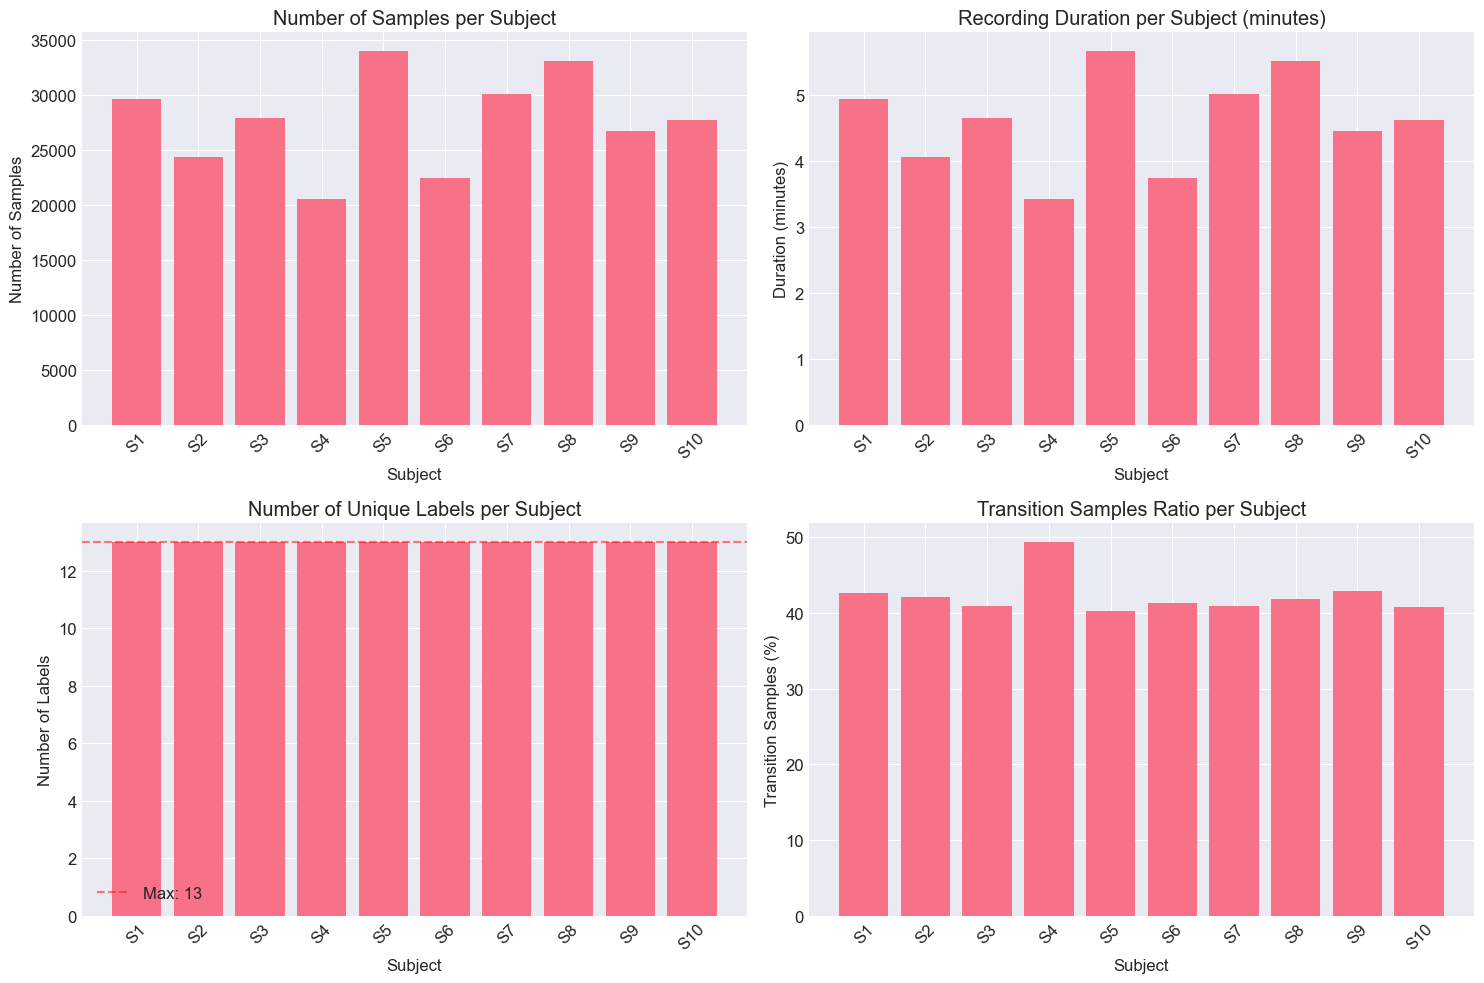

In [14]:
# Plot subject statistics
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Sample count per subject
axes[0, 0].bar(summary_df['subject'], summary_df['total_samples'])
axes[0, 0].set_title('Number of Samples per Subject')
axes[0, 0].set_xlabel('Subject')
axes[0, 0].set_ylabel('Number of Samples')
axes[0, 0].tick_params(axis='x', rotation=45)

# Duration per subject
axes[0, 1].bar(summary_df['subject'], summary_df['duration_seconds'] / 60)
axes[0, 1].set_title('Recording Duration per Subject (minutes)')
axes[0, 1].set_xlabel('Subject')
axes[0, 1].set_ylabel('Duration (minutes)')
axes[0, 1].tick_params(axis='x', rotation=45)

# Unique labels per subject
axes[1, 0].bar(summary_df['subject'], summary_df['unique_labels'])
axes[1, 0].set_title('Number of Unique Labels per Subject')
axes[1, 0].set_xlabel('Subject')
axes[1, 0].set_ylabel('Number of Labels')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=CONFIG['num_classes'], color='r', linestyle='--', alpha=0.5, label=f'Max: {CONFIG["num_classes"]}')
axes[1, 0].legend()

# Transition ratio
axes[1, 1].bar(summary_df['subject'], summary_df['transition_ratio'] * 100)
axes[1, 1].set_title('Transition Samples Ratio per Subject')
axes[1, 1].set_xlabel('Subject')
axes[1, 1].set_ylabel('Transition Samples (%)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Label Distribution Analysis

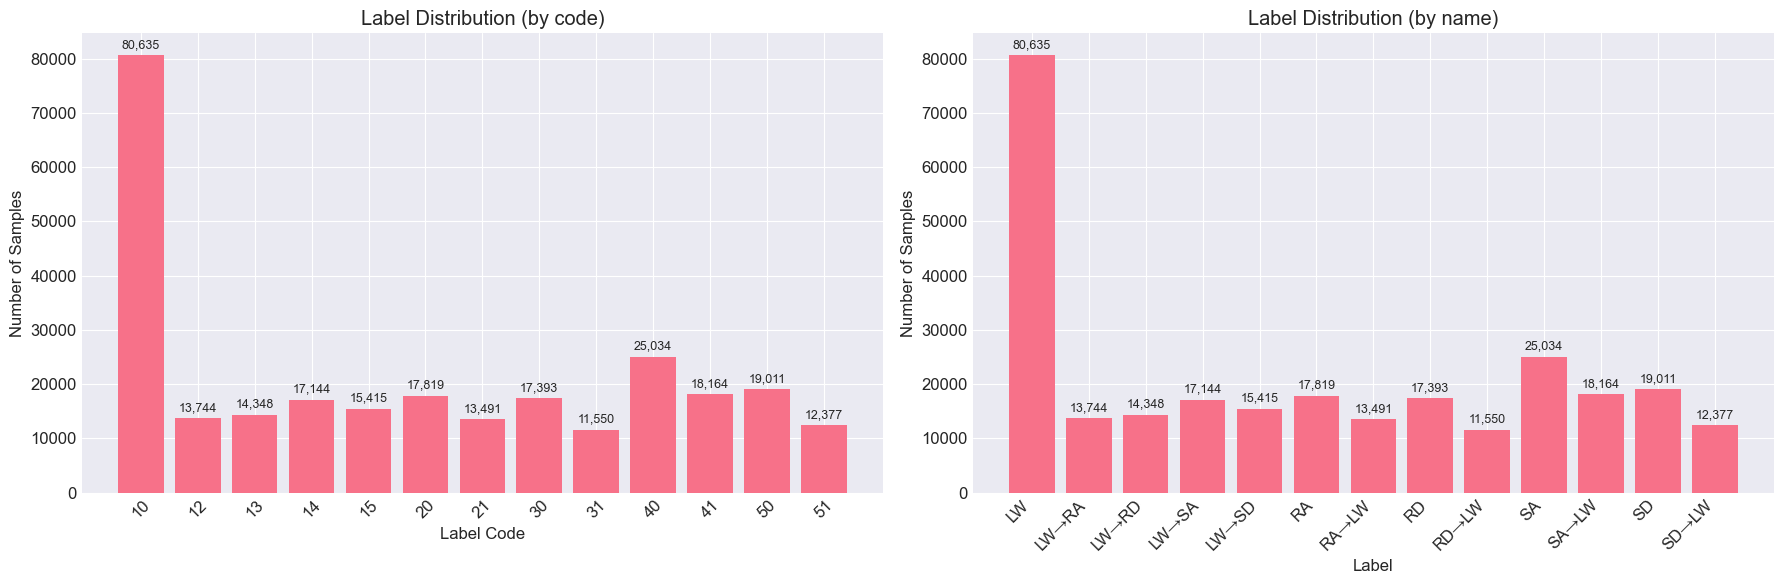

In [15]:
# Combine all data for label analysis
combined_df = pd.concat(all_data.values(), ignore_index=True)

# Label distribution
label_counts = combined_df['label'].value_counts().sort_index()
label_str_counts = combined_df['label_str'].value_counts()

# Plot label distribution
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar plot by label code
bars = axes[0].bar(range(len(label_counts)), label_counts.values)
axes[0].set_title('Label Distribution (by code)')
axes[0].set_xlabel('Label Code')
axes[0].set_ylabel('Number of Samples')
axes[0].set_xticks(range(len(label_counts)))
axes[0].set_xticklabels(label_counts.index, rotation=45)

# Add count on top of bars
for bar, count in zip(bars, label_counts.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + max(label_counts.values)*0.01,
                f'{count:,}', ha='center', va='bottom', fontsize=9)

# Bar plot by label string (sorted)
label_str_counts_sorted = label_str_counts.sort_index()
bars = axes[1].bar(range(len(label_str_counts_sorted)), label_str_counts_sorted.values)
axes[1].set_title('Label Distribution (by name)')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Number of Samples')
axes[1].set_xticks(range(len(label_str_counts_sorted)))
axes[1].set_xticklabels(label_str_counts_sorted.index, rotation=45, ha='right')

# Add count on top of bars
for bar, count in zip(bars, label_str_counts_sorted.values):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + max(label_str_counts_sorted.values)*0.01,
                f'{count:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

In [16]:
# Calculate class imbalance
total_samples = len(combined_df)
imbalance_stats = []

for label, count in label_counts.items():
    label_name = CONFIG['label_mapping'].get(label, str(label))
    percentage = (count / total_samples) * 100
    imbalance_stats.append({
        'label': label,
        'label_name': label_name,
        'count': count,
        'percentage': percentage,
        'is_transition': label in CONFIG['transitions']
    })

imbalance_df = pd.DataFrame(imbalance_stats).sort_values('percentage', ascending=False)

print("Class Imbalance Analysis:")
print(imbalance_df.to_string(index=False))

Class Imbalance Analysis:
 label label_name  count  percentage  is_transition
    10         LW  80635   29.202354          False
    40         SA  25034    9.066184          False
    50         SD  19011    6.884925          False
    41      SA→LW  18164    6.578180           True
    20         RA  17819    6.453237          False
    30         RD  17393    6.298959          False
    14      LW→SA  17144    6.208782           True
    15      LW→SD  15415    5.582617           True
    13      LW→RD  14348    5.196197           True
    12      LW→RA  13744    4.977456           True
    21      RA→LW  13491    4.885831           True
    51      SD→LW  12377    4.482390           True
    31      RD→LW  11550    4.182888           True


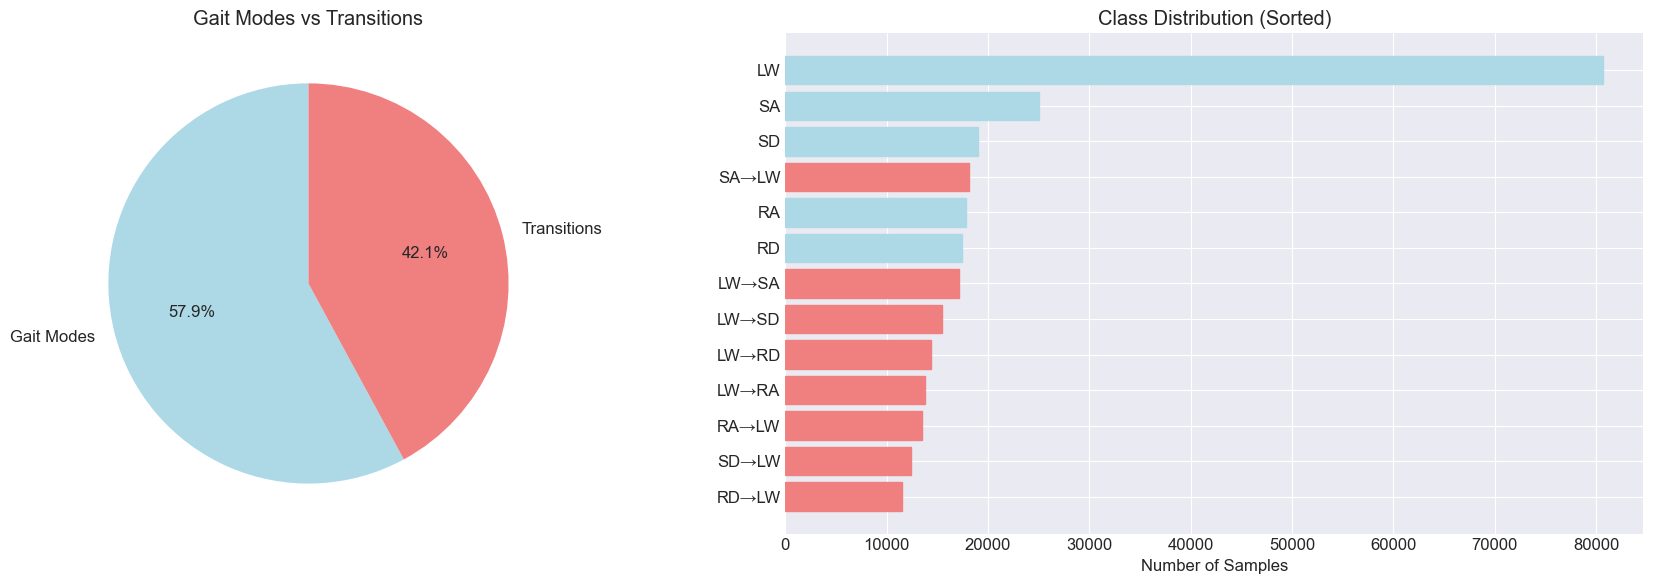

In [17]:
# Visualize class imbalance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Pie chart for gait modes vs transitions
transition_mask = combined_df['label'].isin(CONFIG['transitions'].keys())
transition_count = transition_mask.sum()
gait_mode_count = len(combined_df) - transition_count

axes[0].pie([gait_mode_count, transition_count], 
            labels=['Gait Modes', 'Transitions'],
            autopct='%1.1f%%', startangle=90,
            colors=['lightblue', 'lightcoral'])
axes[0].set_title('Gait Modes vs Transitions')

# Bar plot showing imbalance (sorted)
sorted_labels = imbalance_df.sort_values('count')
bars = axes[1].barh(range(len(sorted_labels)), sorted_labels['count'])
axes[1].set_yticks(range(len(sorted_labels)))
axes[1].set_yticklabels(sorted_labels['label_name'])
axes[1].set_xlabel('Number of Samples')
axes[1].set_title('Class Distribution (Sorted)')

# Color code transitions
for i, (_, row) in enumerate(sorted_labels.iterrows()):
    if row['is_transition']:
        bars[i].set_color('lightcoral')
    else:
        bars[i].set_color('lightblue')

plt.tight_layout()
plt.show()

## 6. Sensor Data Analysis

In [18]:
# Examine sensor data statistics
sensor_stats = {}

for sensor_type, columns in CONFIG['sensor_columns'].items():
    # Check which columns actually exist in the data
    existing_cols = [col for col in columns if col in combined_df.columns]
    
    if existing_cols:
        stats_df = combined_df[existing_cols].describe().T
        sensor_stats[sensor_type] = stats_df
        
        print(f"\n{sensor_type.upper()} Statistics:")
        print(stats_df[['mean', 'std', 'min', 'max']])


ACC_LEFT Statistics:
                mean       std     min      max
x_acc_left  8.113348  8.102504 -65.322  141.224
y_acc_left  1.992707  5.048754 -75.559  114.512
z_acc_left  8.328455  6.651644 -55.782  126.481

ACC_RIGHT Statistics:
                 mean       std     min      max
x_acc_right  7.509970  7.914705 -59.522  154.965
y_acc_right -0.576514  4.672868 -90.159   90.518
z_acc_right  8.572842  6.910015 -98.689  123.200

GYRO_LEFT Statistics:
                 mean       std     min     max
x_gyro_left  0.109564  0.910023 -12.367   6.677
y_gyro_left  0.033994  3.465182 -15.483  10.903
z_gyro_left -0.047646  1.438455  -6.503   8.448

GYRO_RIGHT Statistics:
                  mean       std     min     max
x_gyro_right -0.032979  0.870412 -10.053  11.834
y_gyro_right -0.047940  3.069728 -14.810   9.569
z_gyro_right -0.024181  1.082386  -7.032   6.670

QUAT_LEFT Statistics:
                 mean       std    min    max
quat_1_left -0.003576  0.632224 -0.998  0.998
quat_2_left -0.00

### 6.1 Acceleration Data Analysis

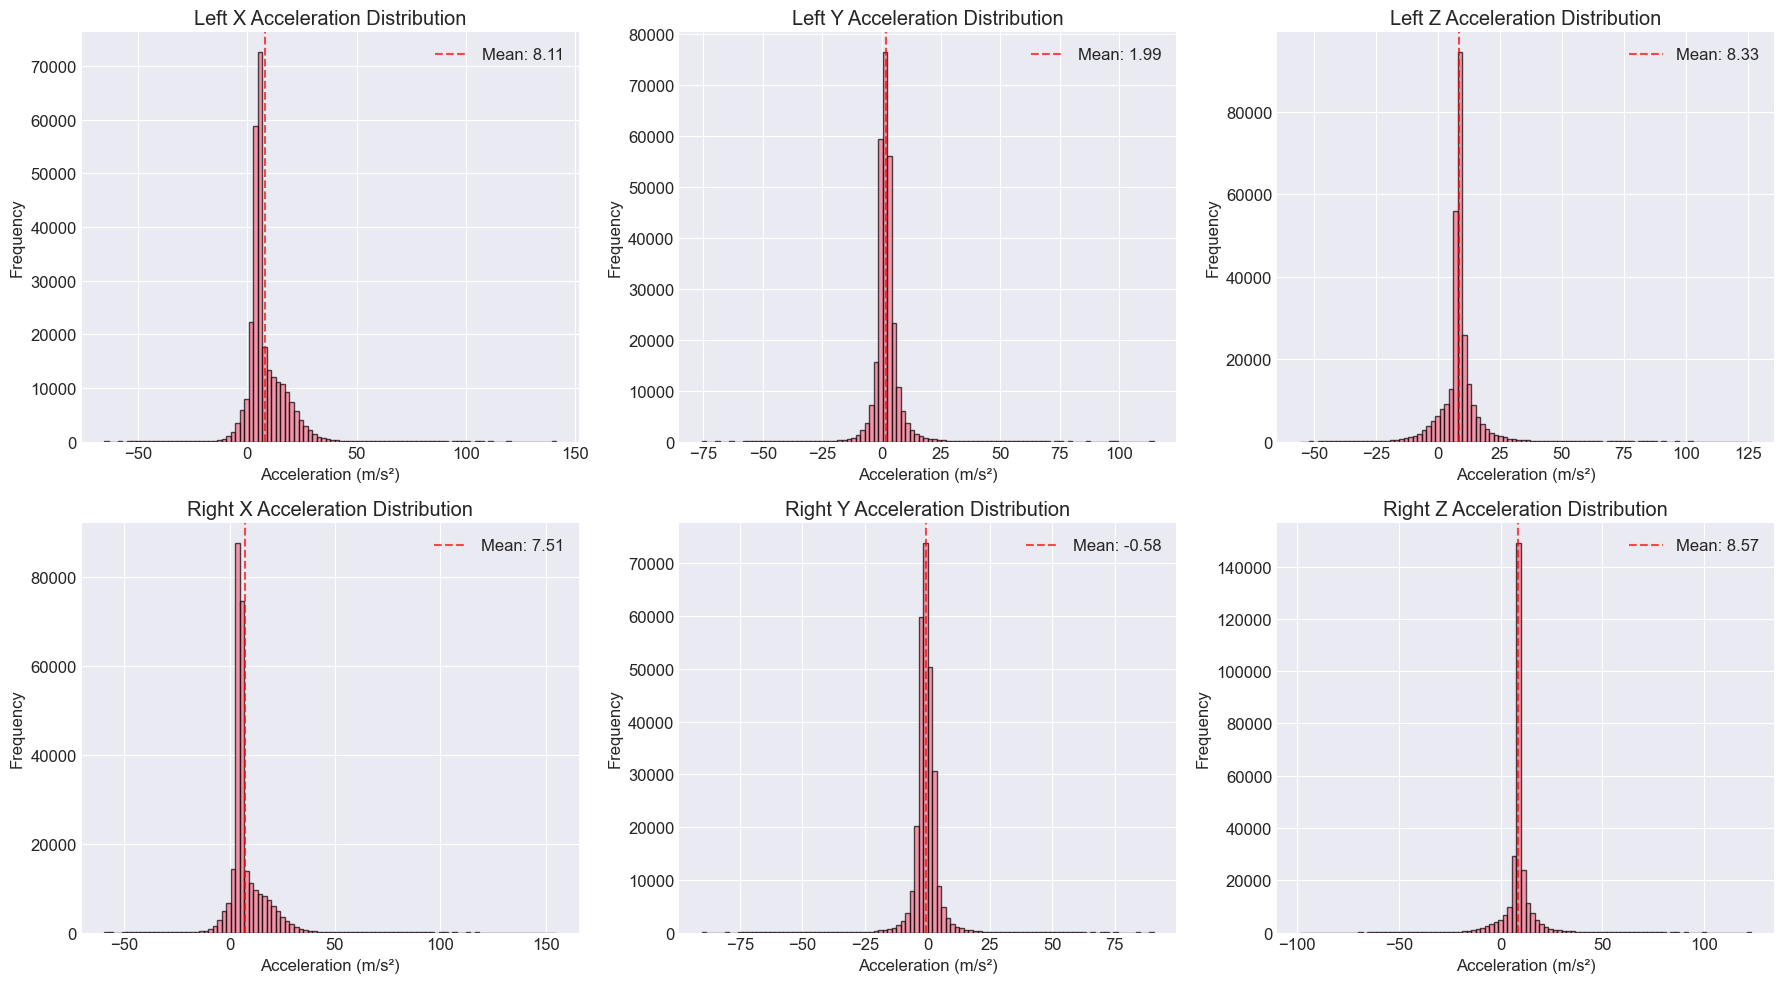

In [19]:
# Plot acceleration data distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
acc_axes = axes.flatten()

acc_columns = CONFIG['sensor_columns']['acc_left'] + CONFIG['sensor_columns']['acc_right']
acc_names = ['Left X', 'Left Y', 'Left Z', 'Right X', 'Right Y', 'Right Z']

for idx, (col, name) in enumerate(zip(acc_columns, acc_names)):
    if col in combined_df.columns:
        acc_axes[idx].hist(combined_df[col].dropna(), bins=100, alpha=0.7, edgecolor='black')
        acc_axes[idx].set_title(f'{name} Acceleration Distribution')
        acc_axes[idx].set_xlabel('Acceleration (m/s²)')
        acc_axes[idx].set_ylabel('Frequency')
        
        # Add vertical line at mean
        mean_val = combined_df[col].mean()
        acc_axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
        acc_axes[idx].legend()

plt.tight_layout()
plt.show()

### 6.2 Gyroscope Data Analysis

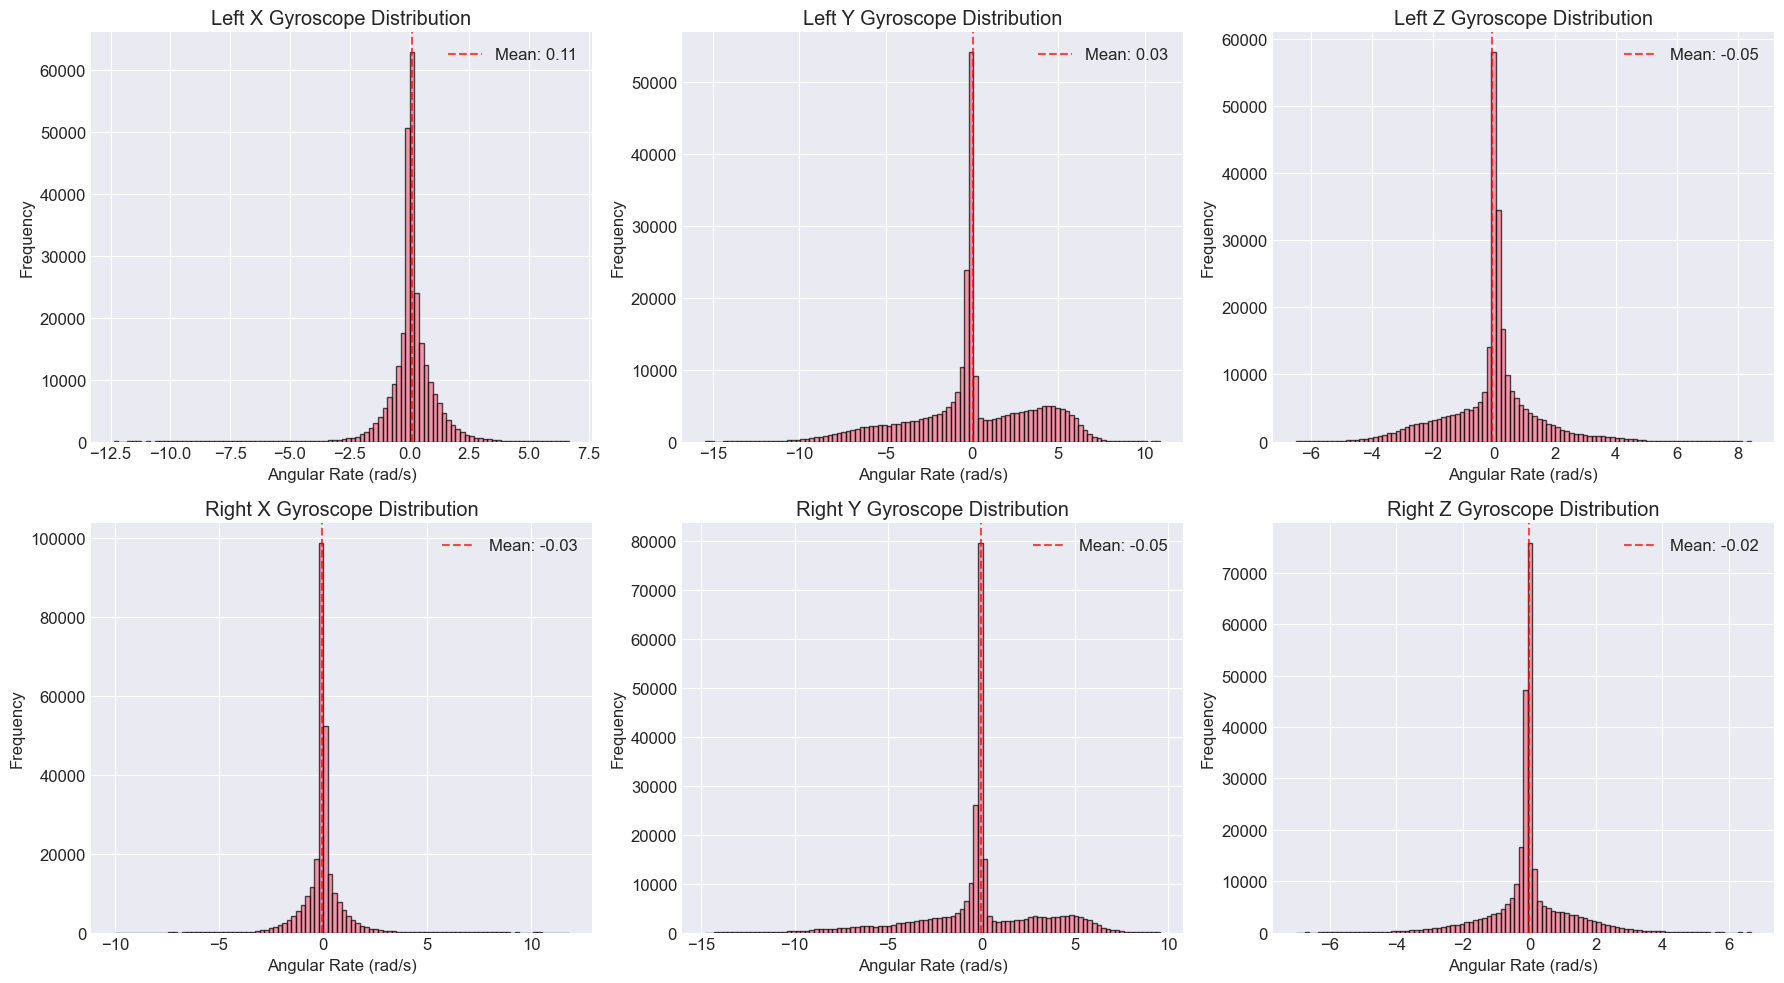

In [20]:
# Plot gyroscope data distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
gyro_axes = axes.flatten()

gyro_columns = CONFIG['sensor_columns']['gyro_left'] + CONFIG['sensor_columns']['gyro_right']
gyro_names = ['Left X', 'Left Y', 'Left Z', 'Right X', 'Right Y', 'Right Z']

for idx, (col, name) in enumerate(zip(gyro_columns, gyro_names)):
    if col in combined_df.columns:
        gyro_axes[idx].hist(combined_df[col].dropna(), bins=100, alpha=0.7, edgecolor='black')
        gyro_axes[idx].set_title(f'{name} Gyroscope Distribution')
        gyro_axes[idx].set_xlabel('Angular Rate (rad/s)')
        gyro_axes[idx].set_ylabel('Frequency')
        
        # Add vertical line at mean
        mean_val = combined_df[col].mean()
        gyro_axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'Mean: {mean_val:.2f}')
        gyro_axes[idx].legend()

plt.tight_layout()
plt.show()

### 6.3 Feature Analysis

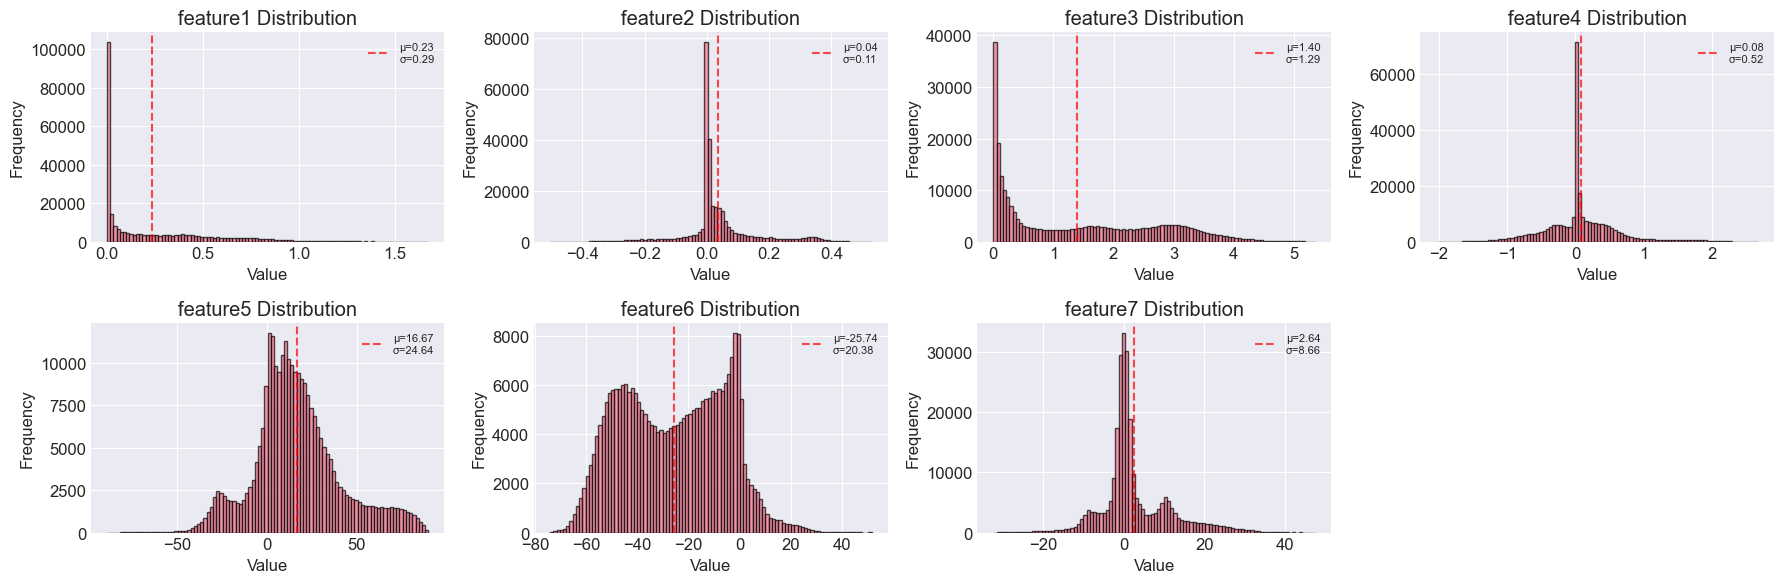

In [21]:
# Plot feature distributions
n_features = len(CONFIG['feature_columns'])
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 3*n_rows))
axes = axes.flatten()

for idx, feature in enumerate(CONFIG['feature_columns']):
    if feature in combined_df.columns:
        axes[idx].hist(combined_df[feature].dropna(), bins=100, alpha=0.7, edgecolor='black')
        axes[idx].set_title(f'{feature} Distribution')
        axes[idx].set_xlabel('Value')
        axes[idx].set_ylabel('Frequency')
        
        # Add statistics
        mean_val = combined_df[feature].mean()
        std_val = combined_df[feature].std()
        axes[idx].axvline(mean_val, color='red', linestyle='--', alpha=0.7, label=f'μ={mean_val:.2f}\nσ={std_val:.2f}')
        axes[idx].legend(fontsize=8)

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()

## 7. Temporal Analysis

In [22]:
def analyze_sequences(subject_df, min_sequence_length=10):
    """Analyze label sequences to understand transitions"""
    labels = subject_df['label'].values
    label_str = subject_df['label_str'].values
    
    sequences = []
    current_label = labels[0]
    current_start = 0
    
    for i in range(1, len(labels)):
        if labels[i] != current_label:
            sequences.append({
                'label': current_label,
                'label_name': label_str[current_start],
                'start': current_start,
                'end': i-1,
                'length': i - current_start,
                'duration': (i - current_start) / CONFIG['sampling_rate']
            })
            current_label = labels[i]
            current_start = i
    
    # Add last sequence
    sequences.append({
        'label': current_label,
        'label_name': label_str[current_start],
        'start': current_start,
        'end': len(labels)-1,
        'length': len(labels) - current_start,
        'duration': (len(labels) - current_start) / CONFIG['sampling_rate']
    })
    
    return pd.DataFrame(sequences)

In [23]:
# Analyze sequences for each subject
all_sequences = []

for subject, df in all_data.items():
    sequences = analyze_sequences(df)
    sequences['subject'] = subject
    all_sequences.append(sequences)

sequences_df = pd.concat(all_sequences, ignore_index=True)

print("Sequence Analysis:")
print(f"Total sequences: {len(sequences_df)}")
print(f"Average sequence length: {sequences_df['length'].mean():.1f} samples")
print(f"Average sequence duration: {sequences_df['duration'].mean():.2f} seconds")
print(f"Median sequence duration: {sequences_df['duration'].median():.2f} seconds")

Sequence Analysis:
Total sequences: 2895
Average sequence length: 95.4 samples
Average sequence duration: 0.95 seconds
Median sequence duration: 1.04 seconds


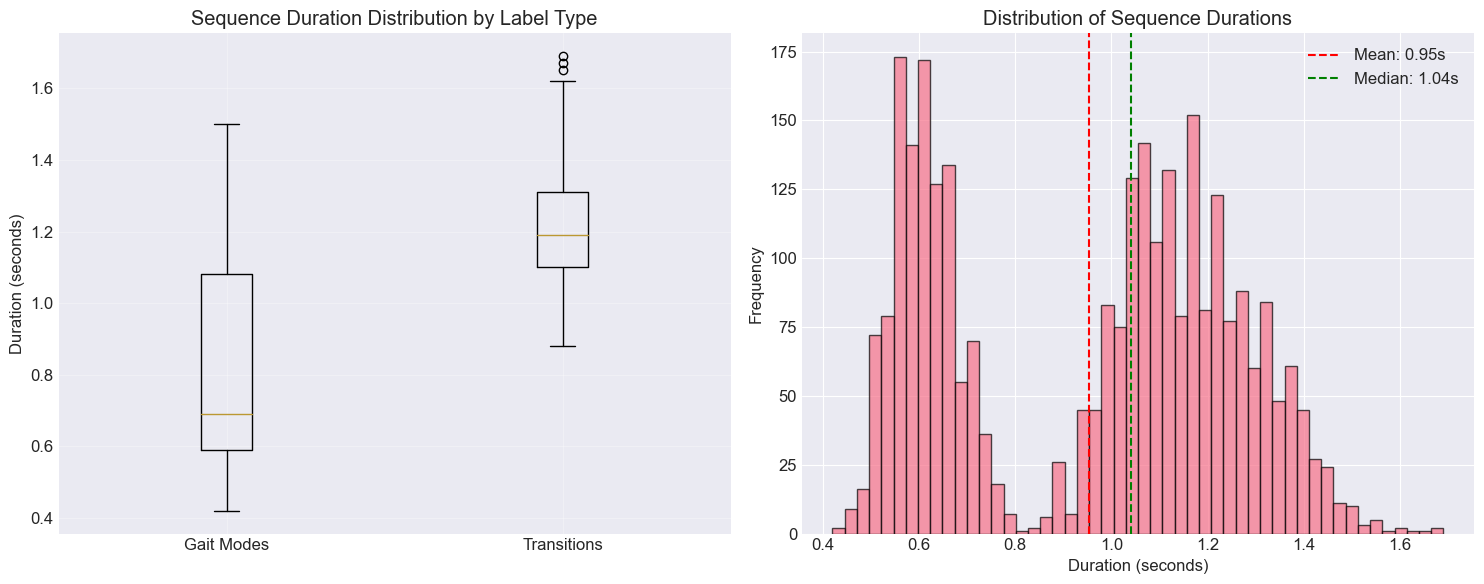

In [24]:
# Plot sequence duration distribution by label type
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Boxplot of sequence durations by label
gait_mode_seqs = sequences_df[sequences_df['label'].isin(CONFIG['gait_modes'].keys())]
transition_seqs = sequences_df[sequences_df['label'].isin(CONFIG['transitions'].keys())]

box_data = [gait_mode_seqs['duration'], transition_seqs['duration']]
box_labels = ['Gait Modes', 'Transitions']

axes[0].boxplot(box_data, labels=box_labels)
axes[0].set_title('Sequence Duration Distribution by Label Type')
axes[0].set_ylabel('Duration (seconds)')
axes[0].grid(True, alpha=0.3)

# Histogram of all sequence durations
axes[1].hist(sequences_df['duration'], bins=50, alpha=0.7, edgecolor='black')
axes[1].set_title('Distribution of Sequence Durations')
axes[1].set_xlabel('Duration (seconds)')
axes[1].set_ylabel('Frequency')
axes[1].axvline(sequences_df['duration'].mean(), color='red', linestyle='--', 
               label=f'Mean: {sequences_df["duration"].mean():.2f}s')
axes[1].axvline(sequences_df['duration'].median(), color='green', linestyle='--',
               label=f'Median: {sequences_df["duration"].median():.2f}s')
axes[1].legend()

plt.tight_layout()
plt.show()

In [47]:
# Analyze sequence durations per gait mode
gait_mode_durations = {}
for label, name in CONFIG['gait_modes'].items():
    label_seqs = sequences_df[sequences_df['label'] == label]
    if len(label_seqs) > 0:
        durations = label_seqs['duration']
        gait_mode_durations[name] = {
            'count': len(label_seqs),
            'min': durations.min(),
            'Q1': durations.quantile(0.25),  # First quartile
            'median': durations.median(),
            'mean': durations.mean(),
            'Q3': durations.quantile(0.75),  # Third quartile
            'max': durations.max(),
            'std': durations.std()
        }

gait_duration_df = pd.DataFrame(gait_mode_durations).T
print("\nGait Mode Duration Statistics (Q1 for d_min recommendation):")
print(gait_duration_df[['count', 'min', 'Q1', 'median', 'mean', 'max', 'std']])

# Print Q1 values separately for d_min selection
print("\n" + "="*60)
print("RECOMMENDED d_min VALUES (using Q1):")
print("="*60)
for mode in sorted(gait_mode_durations.keys()):
    q1_value = gait_mode_durations[mode]['Q1']
    print(f"d_min({mode}): {q1_value:.2f} seconds")


Gait Mode Duration Statistics (Q1 for d_min recommendation):
    count   min     Q1  median      mean   max       std
LW  965.0  0.44  0.590    0.70  0.835596  1.50  0.266783
RA  228.0  0.46  0.600    0.66  0.781535  1.36  0.245878
RD  231.0  0.42  0.540    0.64  0.752944  1.28  0.244924
SA  275.0  0.50  0.630    0.72  0.910327  1.50  0.313149
SD  231.0  0.45  0.595    0.71  0.822987  1.46  0.258417

RECOMMENDED d_min VALUES (using Q1):
d_min(LW): 0.59 seconds
d_min(RA): 0.60 seconds
d_min(RD): 0.54 seconds
d_min(SA): 0.63 seconds
d_min(SD): 0.59 seconds


Taking **Q1** (25th percentile) as dmin is more conservative than median and ensures we filter out 75% of valid durations. This reduces false transitions while allowing natural variability.

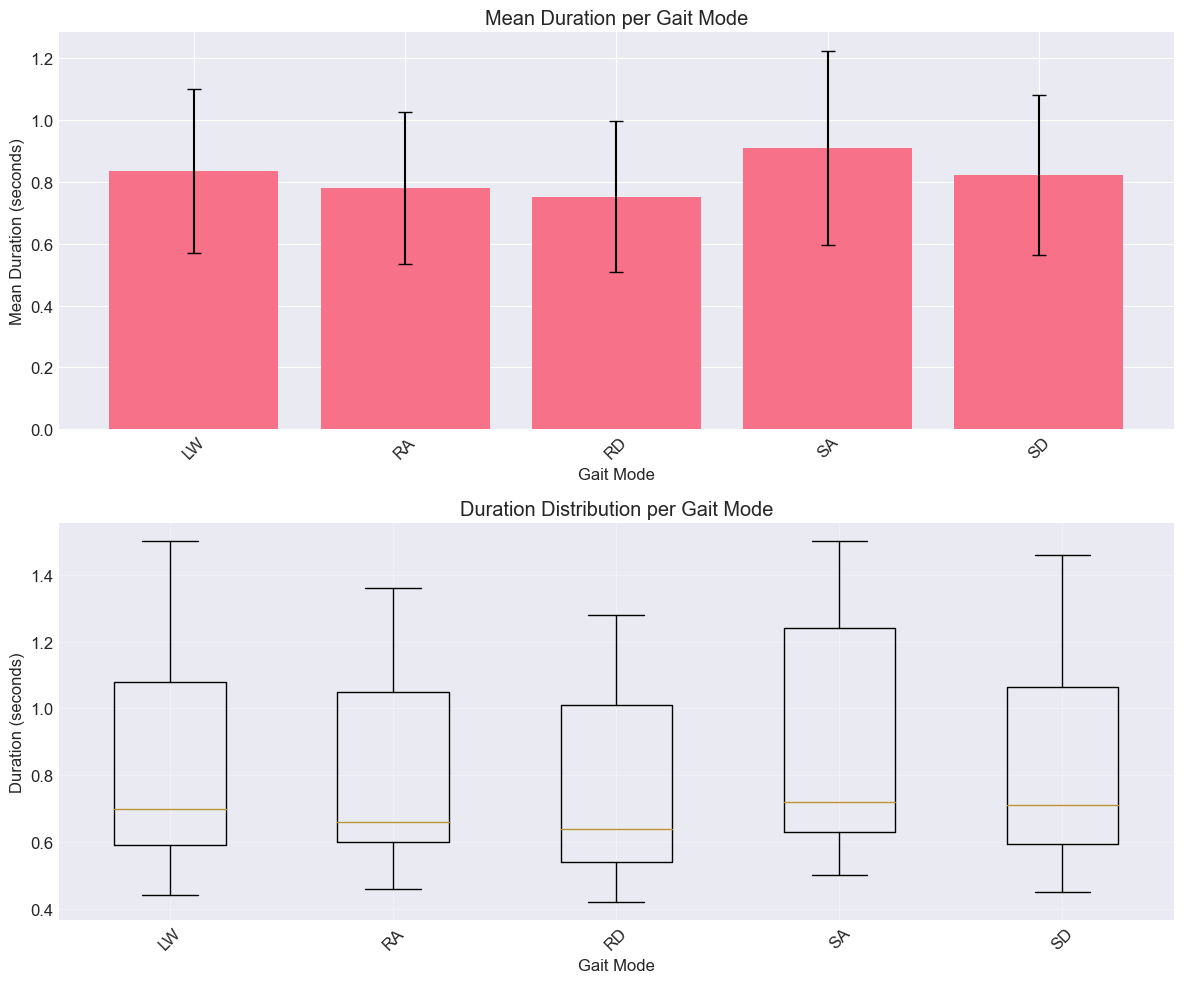

In [26]:
# Plot gait mode durations
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

# Bar plot of mean durations
bars = axes[0].bar(range(len(gait_duration_df)), gait_duration_df['mean'])
axes[0].set_title('Mean Duration per Gait Mode')
axes[0].set_xlabel('Gait Mode')
axes[0].set_ylabel('Mean Duration (seconds)')
axes[0].set_xticks(range(len(gait_duration_df)))
axes[0].set_xticklabels(gait_duration_df.index, rotation=45)

# Add error bars for standard deviation
axes[0].errorbar(range(len(gait_duration_df)), gait_duration_df['mean'],
                yerr=gait_duration_df['std'], fmt='none', ecolor='black', capsize=5)

# Boxplot of durations per gait mode
gait_durations_data = []
for gait_mode in CONFIG['gait_modes'].values():
    mode_seqs = sequences_df[sequences_df['label_name'] == gait_mode]
    if len(mode_seqs) > 0:
        gait_durations_data.append(mode_seqs['duration'].values)

axes[1].boxplot(gait_durations_data, labels=CONFIG['gait_modes'].values())
axes[1].set_title('Duration Distribution per Gait Mode')
axes[1].set_xlabel('Gait Mode')
axes[1].set_ylabel('Duration (seconds)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Correlation Analysis

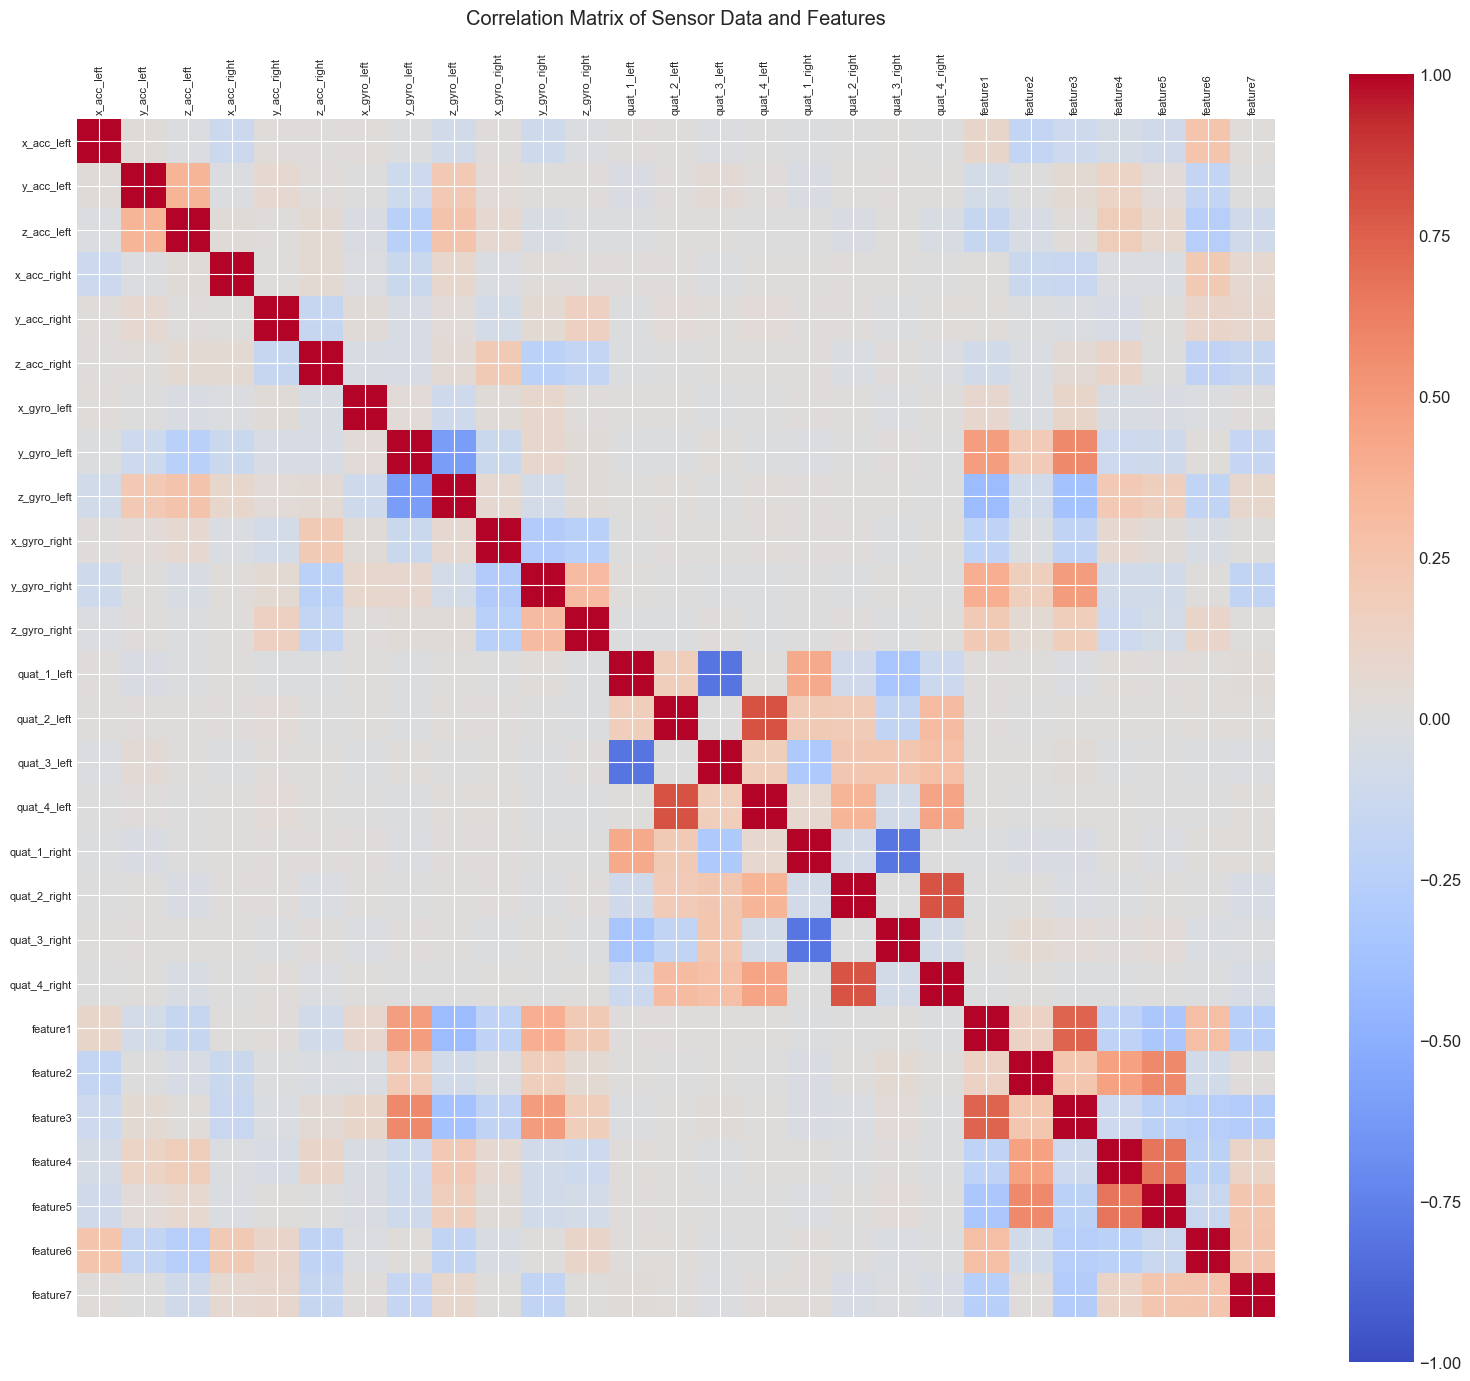

In [27]:
# Calculate correlation matrix for sensor data
sensor_cols = []
for sensor_group in CONFIG['sensor_columns'].values():
    sensor_cols.extend([col for col in sensor_group if col in combined_df.columns])

# Add features
sensor_cols.extend(CONFIG['feature_columns'])

# Calculate correlation matrix (using sample for memory efficiency)
sample_size = min(10000, len(combined_df))
corr_sample = combined_df[sensor_cols].sample(sample_size, random_state=42)
corr_matrix = corr_sample.corr()

# Plot correlation matrix
fig, ax = plt.subplots(figsize=(16, 14))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

# Set ticks
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(corr_matrix.columns, rotation=90, fontsize=8)
ax.set_yticklabels(corr_matrix.columns, fontsize=8)

plt.title('Correlation Matrix of Sensor Data and Features', pad=20)
plt.tight_layout()
plt.show()

In [28]:
# Identify highly correlated features (absolute correlation > 0.8)
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = abs(corr_matrix.iloc[i, j])
        if corr_value > 0.8:
            high_corr_pairs.append({
                'feature1': corr_matrix.columns[i],
                'feature2': corr_matrix.columns[j],
                'correlation': corr_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('correlation', ascending=False)
    print(f"\nFound {len(high_corr_pairs)} pairs with |correlation| > 0.8:")
    print(high_corr_df.head(10))
else:
    print("No highly correlated feature pairs found (|correlation| > 0.8)")


Found 2 pairs with |correlation| > 0.8:
       feature1      feature2  correlation
1  quat_1_right  quat_3_right    -0.804643
0   quat_1_left   quat_3_left    -0.807815


## 9. Subject-wise Analysis

In [29]:
# Analyze differences between subjects
subject_features = {}

for subject, df in all_data.items():
    # Calculate mean values for key features
    subject_features[subject] = {
        'mean_acc_left_mag': np.sqrt(df[['x_acc_left', 'y_acc_left', 'z_acc_left']].pow(2).sum(axis=1)).mean(),
        'mean_acc_right_mag': np.sqrt(df[['x_acc_right', 'y_acc_right', 'z_acc_right']].pow(2).sum(axis=1)).mean(),
        'mean_gyro_left_mag': np.sqrt(df[['x_gyro_left', 'y_gyro_left', 'z_gyro_left']].pow(2).sum(axis=1)).mean(),
        'mean_gyro_right_mag': np.sqrt(df[['x_gyro_right', 'y_gyro_right', 'z_gyro_right']].pow(2).sum(axis=1)).mean(),
        'n_samples': len(df),
        'label_variety': df['label'].nunique()
    }

subject_features_df = pd.DataFrame(subject_features).T

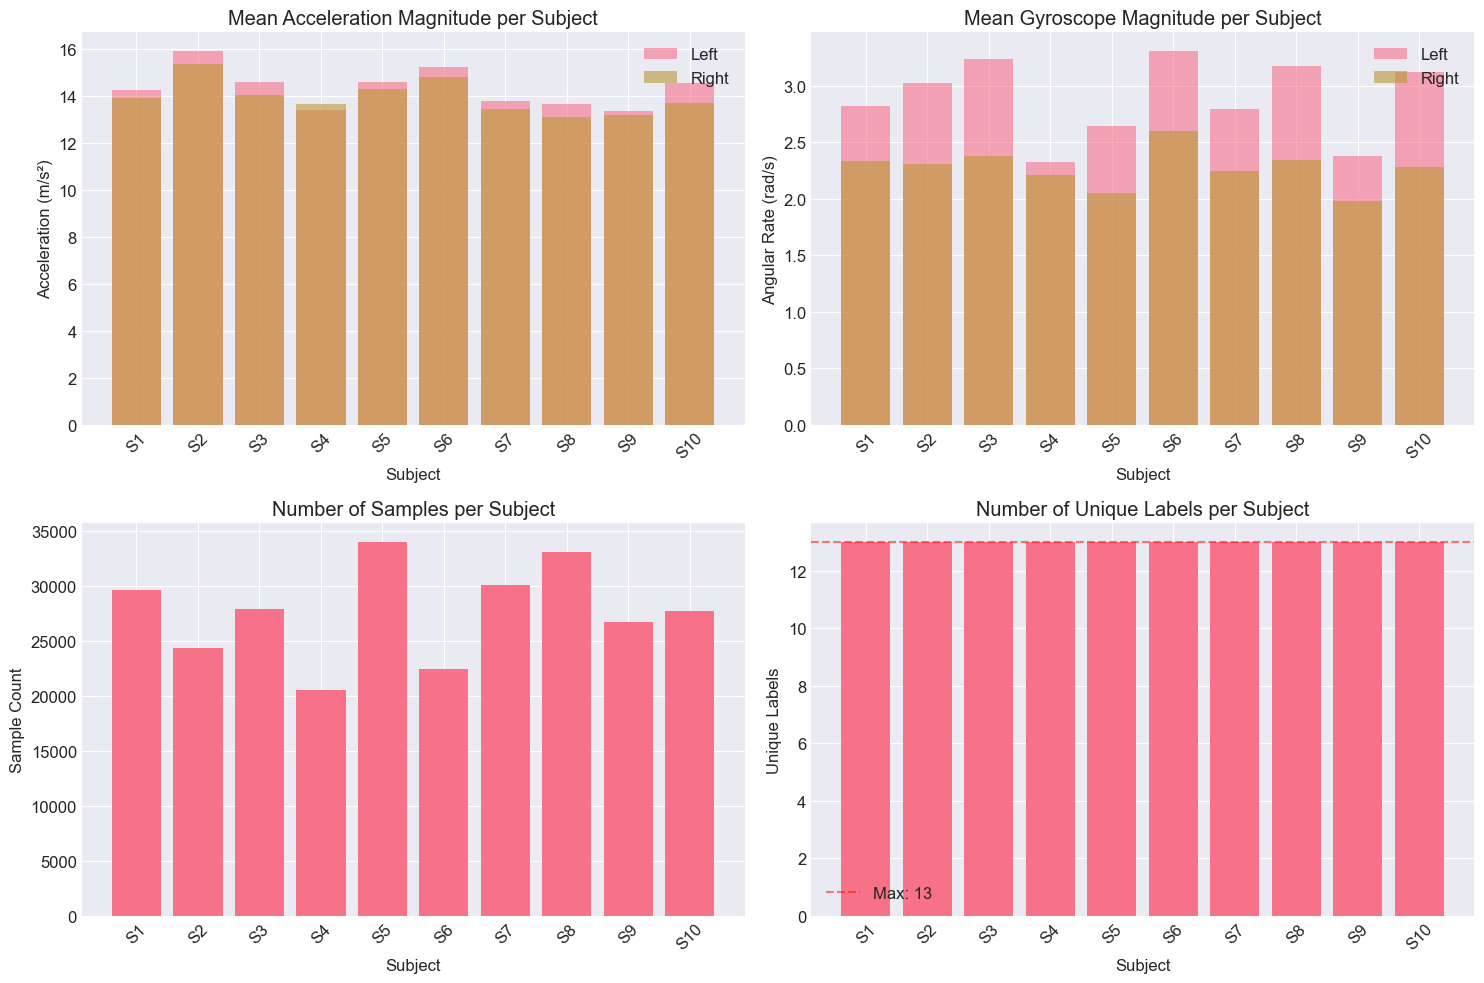

In [30]:
# Plot subject differences
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Acceleration magnitude
axes[0, 0].bar(subject_features_df.index, subject_features_df['mean_acc_left_mag'], alpha=0.6, label='Left')
axes[0, 0].bar(subject_features_df.index, subject_features_df['mean_acc_right_mag'], alpha=0.6, label='Right')
axes[0, 0].set_title('Mean Acceleration Magnitude per Subject')
axes[0, 0].set_xlabel('Subject')
axes[0, 0].set_ylabel('Acceleration (m/s²)')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# Gyroscope magnitude
axes[0, 1].bar(subject_features_df.index, subject_features_df['mean_gyro_left_mag'], alpha=0.6, label='Left')
axes[0, 1].bar(subject_features_df.index, subject_features_df['mean_gyro_right_mag'], alpha=0.6, label='Right')
axes[0, 1].set_title('Mean Gyroscope Magnitude per Subject')
axes[0, 1].set_xlabel('Subject')
axes[0, 1].set_ylabel('Angular Rate (rad/s)')
axes[0, 1].legend()
axes[0, 1].tick_params(axis='x', rotation=45)

# Sample count
axes[1, 0].bar(subject_features_df.index, subject_features_df['n_samples'])
axes[1, 0].set_title('Number of Samples per Subject')
axes[1, 0].set_xlabel('Subject')
axes[1, 0].set_ylabel('Sample Count')
axes[1, 0].tick_params(axis='x', rotation=45)

# Label variety
axes[1, 1].bar(subject_features_df.index, subject_features_df['label_variety'])
axes[1, 1].set_title('Number of Unique Labels per Subject')
axes[1, 1].set_xlabel('Subject')
axes[1, 1].set_ylabel('Unique Labels')
axes[1, 1].axhline(y=CONFIG['num_classes'], color='r', linestyle='--', alpha=0.5, label=f'Max: {CONFIG["num_classes"]}')
axes[1, 1].legend()
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 10. Transition Analysis

In [31]:
# Analyze transition patterns
transition_sequences = sequences_df[sequences_df['label'].isin(CONFIG['transitions'].keys())].copy()

# Add previous and next labels for transition context
transition_contexts = []

for idx, row in transition_sequences.iterrows():
    subject = row['subject']
    subject_df = all_data[subject]
    start_idx = row['start']
    end_idx = row['end']
    
    # Get previous label (if exists)
    prev_label = None
    if start_idx > 0:
        prev_label = subject_df.iloc[start_idx - 1]['label_str']
    
    # Get next label (if exists)
    next_label = None
    if end_idx < len(subject_df) - 1:
        next_label = subject_df.iloc[end_idx + 1]['label_str']
    
    transition_contexts.append({
        'transition': row['label_name'],
        'previous_mode': prev_label,
        'next_mode': next_label,
        'duration': row['duration'],
        'subject': subject
    })

transition_context_df = pd.DataFrame(transition_contexts)

Transition Duration Statistics:
count    965.000000
mean       1.204487
std        0.142843
min        0.880000
25%        1.100000
50%        1.190000
75%        1.310000
max        1.690000
Name: duration, dtype: float64


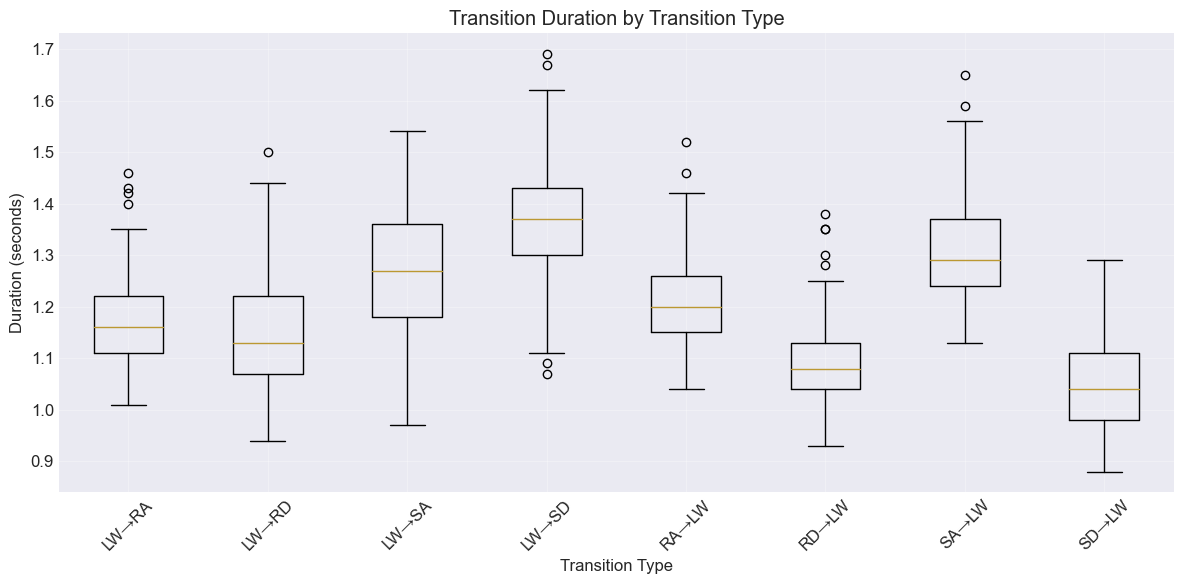

In [32]:
# Analyze transition durations
print("Transition Duration Statistics:")
print(transition_context_df['duration'].describe())

# Plot transition durations by type
plt.figure(figsize=(12, 6))
transition_types = transition_context_df['transition'].unique()
transition_durations = [transition_context_df[transition_context_df['transition'] == t]['duration'].values 
                       for t in transition_types]

plt.boxplot(transition_durations, labels=transition_types)
plt.title('Transition Duration by Transition Type')
plt.xlabel('Transition Type')
plt.ylabel('Duration (seconds)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [33]:
# Analyze transition contexts
print("\nTransition Context Analysis:")
context_counts = transition_context_df.groupby(['transition', 'previous_mode', 'next_mode']).size().reset_index(name='count')
print(context_counts.sort_values('count', ascending=False).head(20))


Transition Context Analysis:
  transition previous_mode next_mode  count
6      SA→LW            SA        LW    139
2      LW→SA            LW        SA    136
1      LW→RD            LW        RD    125
7      SD→LW            SD        LW    118
0      LW→RA            LW        RA    117
3      LW→SD            LW        SD    113
4      RA→LW            RA        LW    111
5      RD→LW            RD        LW    106


## 12. Data Quality Checks

In [43]:
combined_df.head()

,time,x_acc_left,y_acc_left,z_acc_left,x_acc_right,y_acc_right,z_acc_right,quat_1_left,quat_2_left,quat_3_left,...,feature3,feature4,feature5,feature6,feature7,label,subject,label_str,is_transition,gait_mode
0,129,2.827,0.571,9.472,5.086,-2.455,16.864,0.163,-0.273,-0.078,...,0.070,0.010,29.222,-5.308,18.640,10,S1,LW,False,LW
1,130,3.027,0.526,9.339,3.855,-3.400,18.089,0.163,-0.286,-0.082,...,0.087,0.008,24.133,-6.731,16.572,10,S1,LW,False,LW
2,131,3.177,0.464,9.379,6.652,-3.799,12.205,0.163,-0.303,-0.085,...,0.106,0.005,19.499,-8.432,14.358,10,S1,LW,False,LW
3,132,3.257,0.669,9.263,10.920,-4.446,11.873,0.162,-0.321,-0.088,...,0.125,0.001,15.282,-10.416,11.940,10,S1,LW,False,LW
4,133,3.514,0.824,9.148,12.877,-5.367,17.445,0.161,-0.341,-0.092,...,0.144,-0.003,11.678,-12.666,9.677,10,S1,LW,False,LW


In [44]:
original_csv_columns = combined_df.columns.tolist()
# Remove columns we added during EDA
eda_added_columns = ['subject', 'label_str', 'is_transition', 'gait_mode', 'extended_mode']
original_only_columns = [col for col in original_csv_columns if col not in eda_added_columns]

missing_check = combined_df[original_only_columns].isnull().sum().sum()

if missing_check == 0:
    print("No missing values found in sensor data or labels")
else:
    print(f"Found {missing_check} missing values")
    # Show details
    missing_details = combined_df[original_only_columns].isnull().sum()
    missing_details = missing_details[missing_details > 0]
    print("\nColumns with missing values:")
    for col, count in missing_details.items():
        print(f"  {col}: {count} values")

No missing values found in sensor data or labels


In [45]:
# Check for outliers using IQR method
def detect_outliers_iqr(data, column, threshold=1.5):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

# Check key sensor columns for outliers
print("\nOutlier Detection (IQR method):")
for col in ['x_acc_left', 'y_acc_left', 'z_acc_left', 'feature1', 'feature2']:
    if col in combined_df.columns:
        n_outliers, lower, upper = detect_outliers_iqr(combined_df, col)
        percentage = (n_outliers / len(combined_df)) * 100
        print(f"{col}: {n_outliers} outliers ({percentage:.2f}%), bounds: [{lower:.2f}, {upper:.2f}]")


Outlier Detection (IQR method):
x_acc_left: 19386 outliers (7.02%), bounds: [-7.27, 22.36]
y_acc_left: 21798 outliers (7.89%), bounds: [-5.72, 9.39]
z_acc_left: 62040 outliers (22.47%), bounds: [2.94, 14.13]
feature1: 3808 outliers (1.38%), bounds: [-0.59, 1.01]
feature2: 54151 outliers (19.61%), bounds: [-0.08, 0.13]
